In [1]:
import platform
if 'mac' in platform.platform():
    BASE_DIR = "/Users/USER/vrtopc/"
    DATA_DIR = "/media/data/vrtopc"
else:
    BASE_DIR = "/home/USER/vr_to_pc/"
    DATA_DIR = "/media/data/vrtopc"

import sys
sys.path.append(BASE_DIR)

### Parameters

In [2]:
import numpy as np

SEED = 7
np.random.seed(SEED)

In [ ]:
ENV_SHAPE = "box"

import yaml
import os
with open(os.path.join(BASE_DIR, "real_data_exploration/cluster_locomotion/config.yaml")) as f:
    config = yaml.safe_load(f)

DT = 1./config['FPS']

BOX_LENGTH = config['BOX_DIM']+2*config['BOX_EPS'] # m

DF_DAMP = 1./(2*config['FPS']) # DF damp (DF^(DF_DAMP*i))
K = config['FPS']*config['THRESHOLD_SEC'] # seconds
B = config['B']
B_HD = config['B_HD']
HALF_IDX = B**2//2
BOX_LENGTH_LOWER_TH = BOX_LENGTH - BOX_LENGTH/B

### Imports

In [4]:
import time
import matplotlib.pyplot as plt
import pandas as pd

### Load Real Data

In [5]:
mat_dir = os.path.join(DATA_DIR, 'real_data')

##### Processed Struct Data

In [6]:
from real_data_exploration.utils.data_loader import load_data_struct

load_dirs_struct = [
    'muessig_data_struct',
    'science2010_data_struct',
    'SCAN structure - adn_struct',
    'SCAN structure - presub_adult_struct',
    'SCAN structure - presub_pup_oldrats_struct',
    'rawData_ento_all_pup_struct'
]

data_ld_struct_dict, ratnames = load_data_struct(mat_dir, load_dirs_struct, keep_full_ratname=True)

muessig_data_struct
r732_P26
	1 trial(s)

r572_P20
	1 trial(s)

r1783_P20
	2 trial(s)

r1776_P18
	2 trial(s)

r1770_P19
	3 trial(s)

r14_P18
	3 trial(s)

r1776_P20
	2 trial(s)

r67_P17
	3 trial(s)

r379_P28
	2 trial(s)

r98_P19
	3 trial(s)

r1770_P18
	2 trial(s)

r44_P40
	2 trial(s)

r711_P22
	1 trial(s)

r118_P26
	3 trial(s)

r716_P26
	1 trial(s)

r1783_P15
	3 trial(s)

r732_P31
	1 trial(s)

r739_P30
	1 trial(s)

r566_P17
	2 trial(s)

r378_P30
	2 trial(s)

r72_P20
	3 trial(s)

r66_P18
	3 trial(s)

r663_P19
	2 trial(s)

r66_P16
	3 trial(s)

r1770_P15
	2 trial(s)

r572_P22
	1 trial(s)

r1771_P14
	2 trial(s)

r1917_P19
	2 trial(s)

r631_P18
	2 trial(s)

r573_P20
	1 trial(s)

r596_P22
	2 trial(s)

r86_P18
	3 trial(s)

r733_P28
	1 trial(s)

r1776_P16
	2 trial(s)

r574_P18
	2 trial(s)

r85_P17
	3 trial(s)

r129_P40
	2 trial(s)

r586_P24
	1 trial(s)

r27_P40
	2 trial(s)

r710_P22
	1 trial(s)

r97_P17
	3 trial(s)

r378_P29
	2 trial(s)

r724_P25
	1 trial(s)

r739_P29
	1 trial(s)

r65_P19
	3 tr

In [7]:
ratnames_age = sorted([
    r.lower() for ld in load_dirs_struct for r in data_ld_struct_dict[ld].keys()
])
ratnames_old = sorted(ratnames)

##### Info

In [8]:
data_ld_dict = data_ld_struct_dict

In [9]:
ages_ld = {}
sample_rates = []
print('--------------------------------')

for ld, data_dict in data_ld_dict.items():
    print(ld)
    print()
    ages = []
    for k, v in data_dict.items():
        print(k)
        print('keys', list(v.keys()))
        print('ages', [int(a.split('_')[0]) for a in v.keys()])
        print()
        for age, exp in v.items():
            sr_tmp = [t['sample_rate'] for t in exp['trials']]
            sample_rates += sr_tmp
            print(f"environments {[t['environment'] for t in exp['trials']]}")
            print(f"ppm {[t['ppm'] for t in exp['trials']]}")
            print(f"sample rates {sr_tmp}")
            ages += [int(age.split('_')[0])]*len(exp['trials'])
        print()
        print('--------------------------------')
    ages_ld[ld] = ages

--------------------------------
muessig_data_struct

r732_p26
keys ['26']
ages [26]

environments ['hp']
ppm [array([400], dtype=uint16)]
sample rates [np.uint8(50)]

--------------------------------
r572_p20
keys ['20']
ages [20]

environments ['hp']
ppm [array([400], dtype=uint16)]
sample rates [np.uint8(50)]

--------------------------------
r1783_p20
keys ['20']
ages [20]

environments ['hp', 'hp']
ppm [array([400], dtype=uint16), array([400], dtype=uint16)]
sample rates [np.uint8(50), np.uint8(50)]

--------------------------------
r1776_p18
keys ['18']
ages [18]

environments ['hp', 'hp']
ppm [array([400], dtype=uint16), array([400], dtype=uint16)]
sample rates [np.uint8(50), np.uint8(50)]

--------------------------------
r1770_p19
keys ['19']
ages [19]

environments ['hp', 'hp', 'hp']
ppm [array([400], dtype=uint16), array([400], dtype=uint16), array([400], dtype=uint16)]
sample rates [np.uint8(50), np.uint8(50), np.uint8(50)]

--------------------------------
r14_p18
keys ['1

In [10]:
import collections
print(collections.Counter(sample_rates))

Counter({np.uint8(50): 1537, np.float64(46.875): 177})


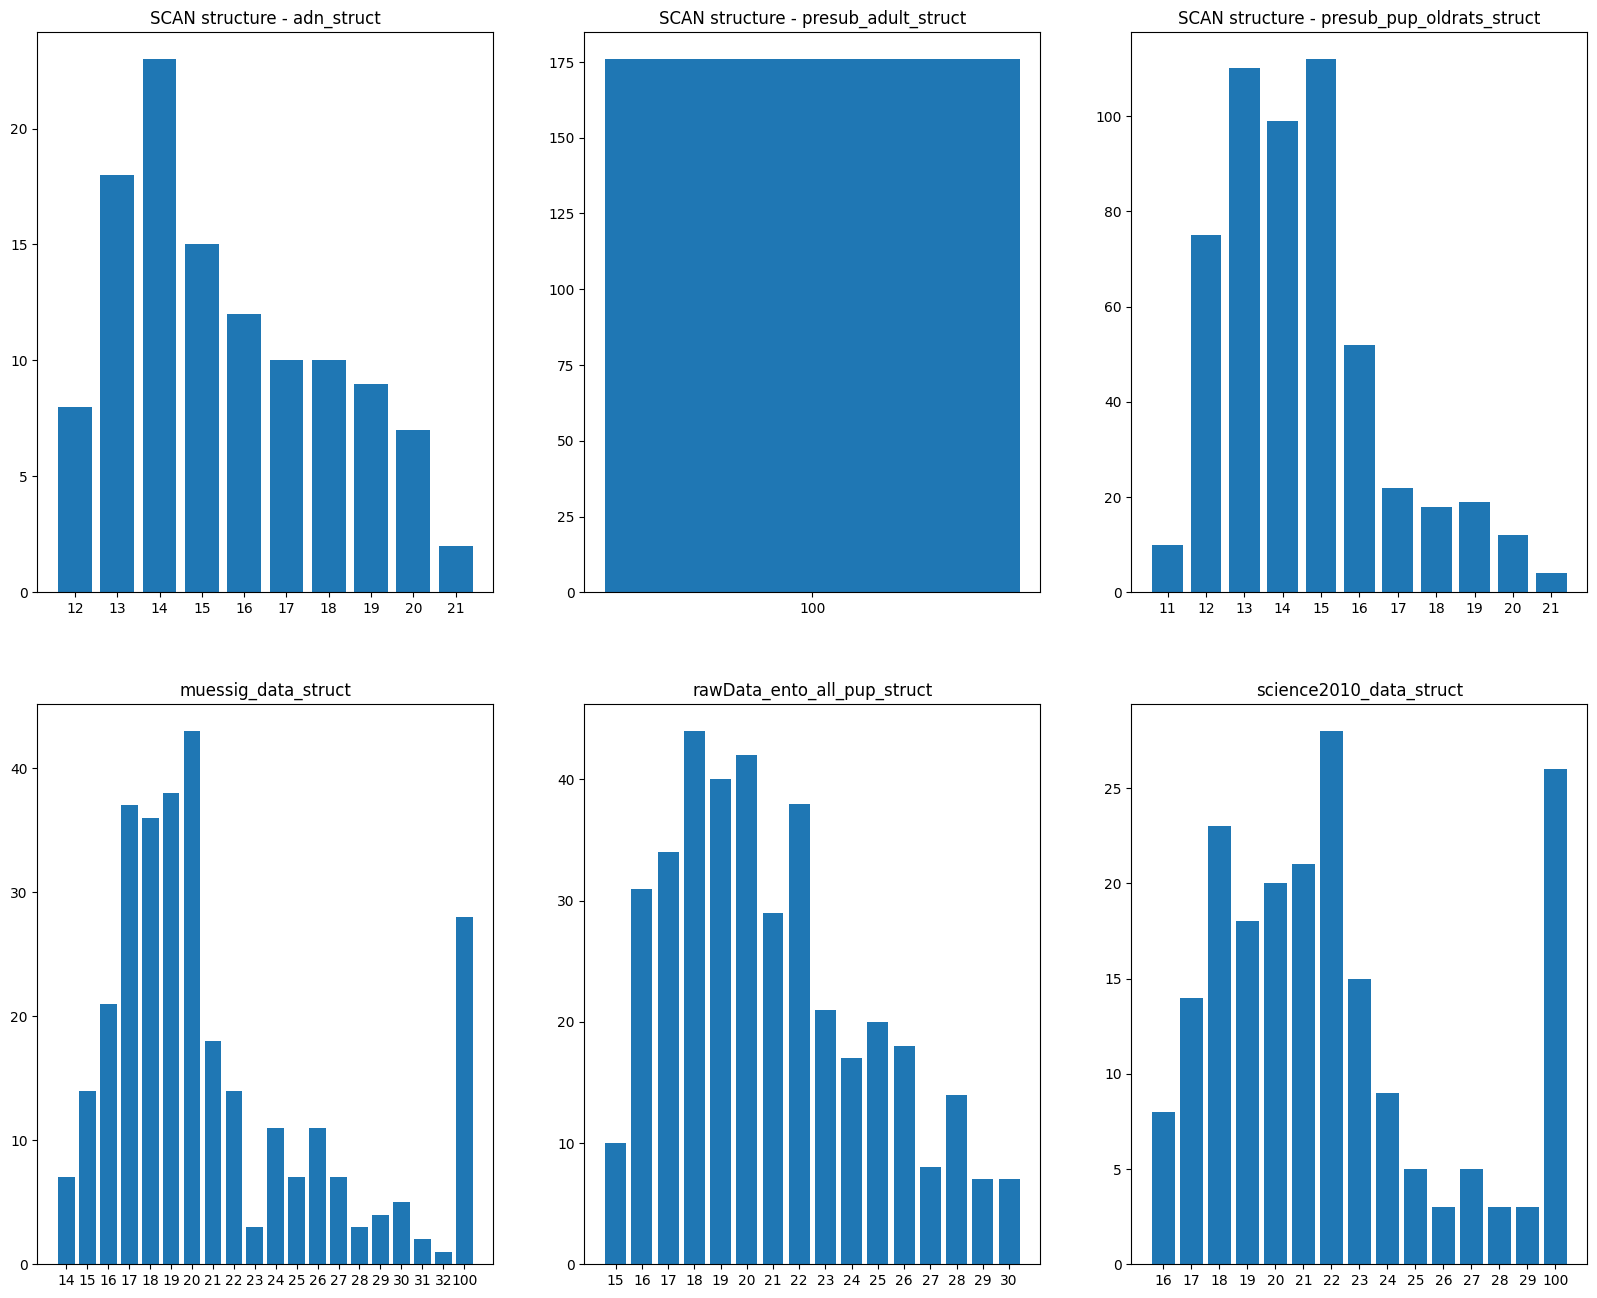

In [11]:
fig, axs = plt.subplots(2, int(np.ceil(len(ages_ld.keys())/2)), figsize=(20, 16))
idx = 0
for ld in sorted(ages_ld.keys()):
    c = collections.Counter(ages_ld[ld])
    ages = sorted(list(np.unique(ages_ld[ld])))

    axs.flat[idx].bar(range(len(ages)), [c[a] for a in ages])
    axs.flat[idx].set_xticks(range(len(ages)))
    axs.flat[idx].set_xticklabels(ages, fontsize=10)
    axs.flat[idx].set_title(ld[:50], fontsize=12)
    idx+=1
plt.show()

### Rat Behavioural Analysis

##### Preprocess positions and Pick random samples

In [12]:
from real_data_exploration.utils.process_data import filter_trial, plot_trajectory

BOX_TOL = 2.5*config['BOX_EPS']

# plot params
PLOT_TRAJ = False
plt_every = 5
ticks = np.round(np.linspace(0, BOX_LENGTH, 11), 2)

In [13]:
x_dict = {}
y_dict = {}
hd_dict = {}
speed_dict = {}
rs_dict = {}
dur_dict = {}

box_size = {}

counter_by_age = {}
duration_by_age = {}
box_size = {}

for ld, dd in data_ld_dict.items():
    i = 0
    if ld not in counter_by_age.keys():
        box_size[ld] = {}
    for k, v in dd.items():
        for age_key, exp in v.items():
            age = int(age_key.split('_')[0])
            for trial in exp['trials']:
                out = filter_trial(
                    trial, ld, k, age_key,
                    config['SMOOTH_THETA'], config['FPS'], config['DURATION_RANGE'], BOX_LENGTH, config['BOX_EPS'], BOX_TOL, BOX_LENGTH_LOWER_TH,
                )
                if out is None:
                    continue

                if age not in counter_by_age.keys():
                    counter_by_age[age] = 0
                    duration_by_age[age] = []
                if age not in box_size[ld].keys():
                    box_size[ld][age] = []

                x, y, hd, speed, rot_speed, duration = out
                x_dict[(ld, k, age, counter_by_age[age])] = x
                y_dict[(ld, k, age, counter_by_age[age])] = y
                hd_dict[(ld, k, age, counter_by_age[age])] = hd
                speed_dict[(ld, k, age, counter_by_age[age])] = speed
                rs_dict[(ld, k, age, counter_by_age[age])] = rot_speed
                dur_dict[(ld, k, age, counter_by_age[age])] = duration

                counter_by_age[age] += 1
                duration_by_age[age].append(duration)
                box_size[ld][age].append(np.array([np.min(x), np.min(y), np.max(x), np.max(y)]))

                if PLOT_TRAJ:
                    if i%plt_every == 0:
                        if i > 0:
                            plt.show()
                            plt.close()
                        fig, axs = plt.subplots(1, plt_every, figsize=(15,3))
                    title = f"{k} {age} {trial['name']}"
                    plot_trajectory(axs[i%plt_every], x, y, ticks, config['BOX_LENGTH'], max(x), max(y), title)
                    i += 1

                # un-comment to produce nicer plot
                # if plot_traj and k=='r13' and age ==18 and trial['name']=='110401d':
                #     plt.figure(figsize=(7,7))

                #     plt.scatter(x, y, s=15, color='#095CE6')
                #     # plt.plot(x, y, lw=5, color='#095CE6')
                #     # plt.set_xlim([0, box_length])
                #     # plt.set_ylim([0, box_length])

                #     plt.xticks([])
                #     plt.yticks([])
                #     # axs[i%plt_every].grid()
                #     title = f"{k} {age} {trial['name']}"
                #     # if np.max(x) < 0.9*box_length or np.max(y) < 0.9*box_length:
                #     #     title += f": {count_x_closetomax}, {count_y_closetomax}"
                #     plt.suptitle(
                #         title, fontsize=30
                #     )
                #     i += 1
                #     plt.tight_layout()
                #     plt.savefig("figures/real_traj.png")
                #     plt.show()
                #     break

print("Number of trajectories by age:")
print({a: counter_by_age[a] for a in sorted(counter_by_age.keys())})

Skipping science2010_data_struct, r1308_d4, 100, 0 because sample rate is not 50 Hz, environment is not hp, or duration < 300 s
Skipping science2010_data_struct, r1308_d4, 100, 1 because sample rate is not 50 Hz, environment is not hp, or duration < 300 s
Skipping science2010_data_struct, r1308_d4, 100, 2 because sample rate is not 50 Hz, environment is not hp, or duration < 300 s
Skipping science2010_data_struct, r1526_p18, 18, 0 because sample rate is not 50 Hz, environment is not hp, or duration < 300 s
Skipping science2010_data_struct, r1477_p29, 29, 0 because sample rate is not 50 Hz, environment is not hp, or duration < 300 s
Skipping science2010_data_struct, r1477_p29, 29, 1 because sample rate is not 50 Hz, environment is not hp, or duration < 300 s
Skipping science2010_data_struct, r1477_p29, 29, 2 because sample rate is not 50 Hz, environment is not hp, or duration < 300 s
Skipping science2010_data_struct, r1515_p23, 23, 0 because sample rate is not 50 Hz, environment is not 

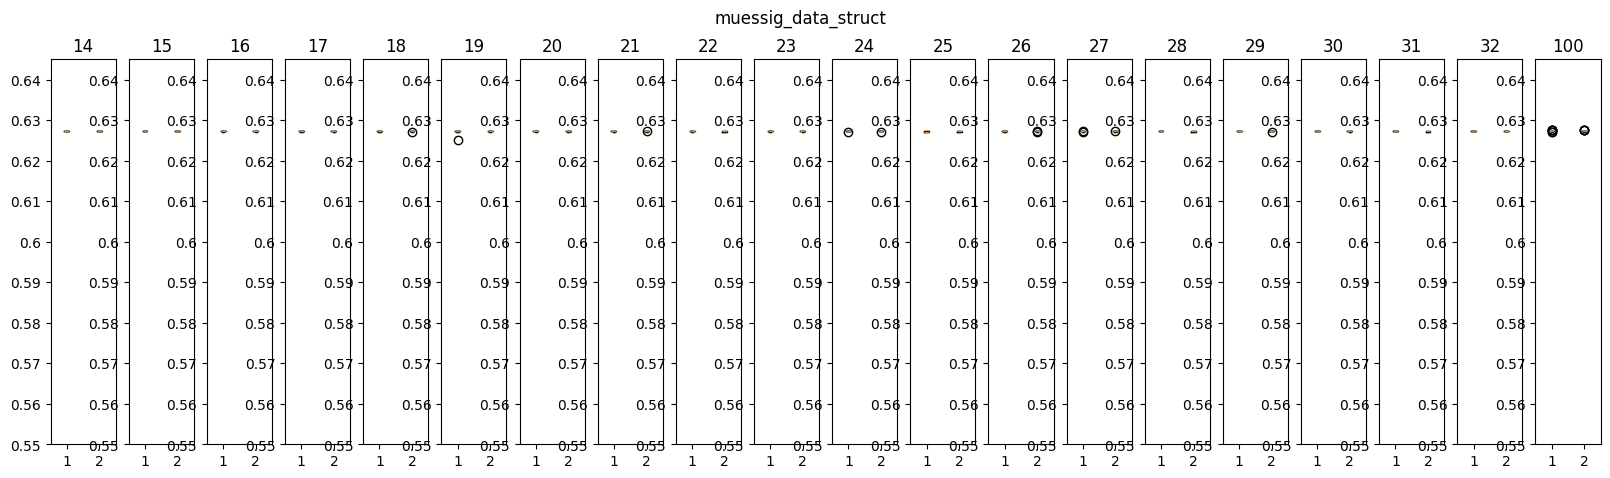

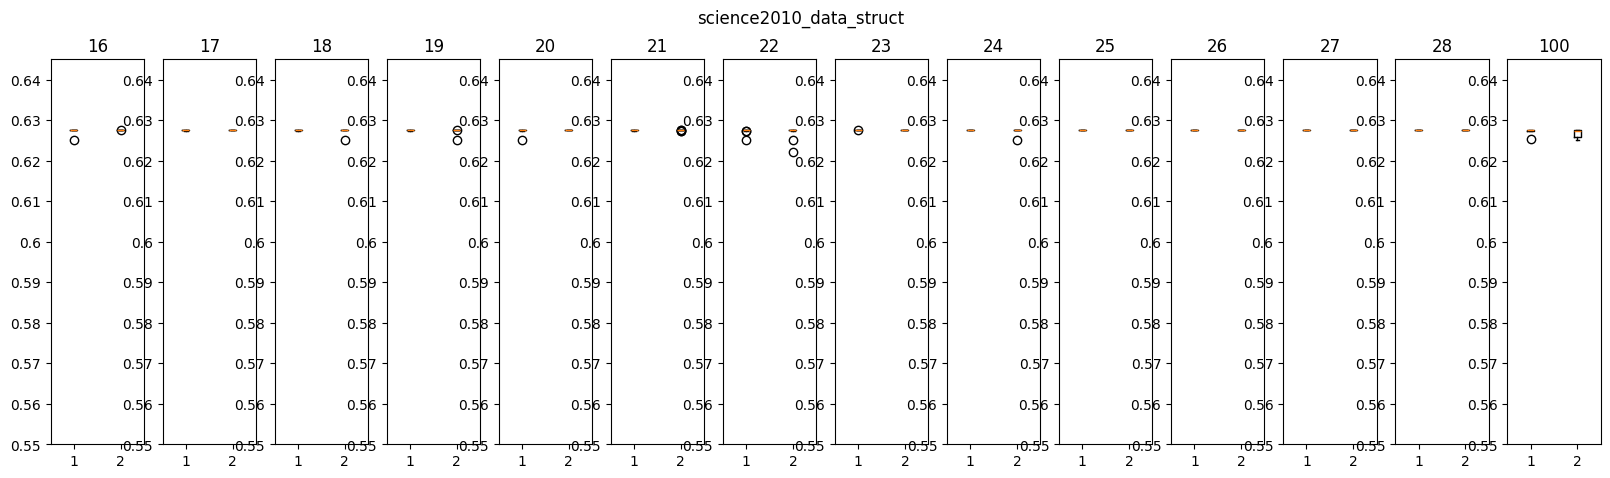

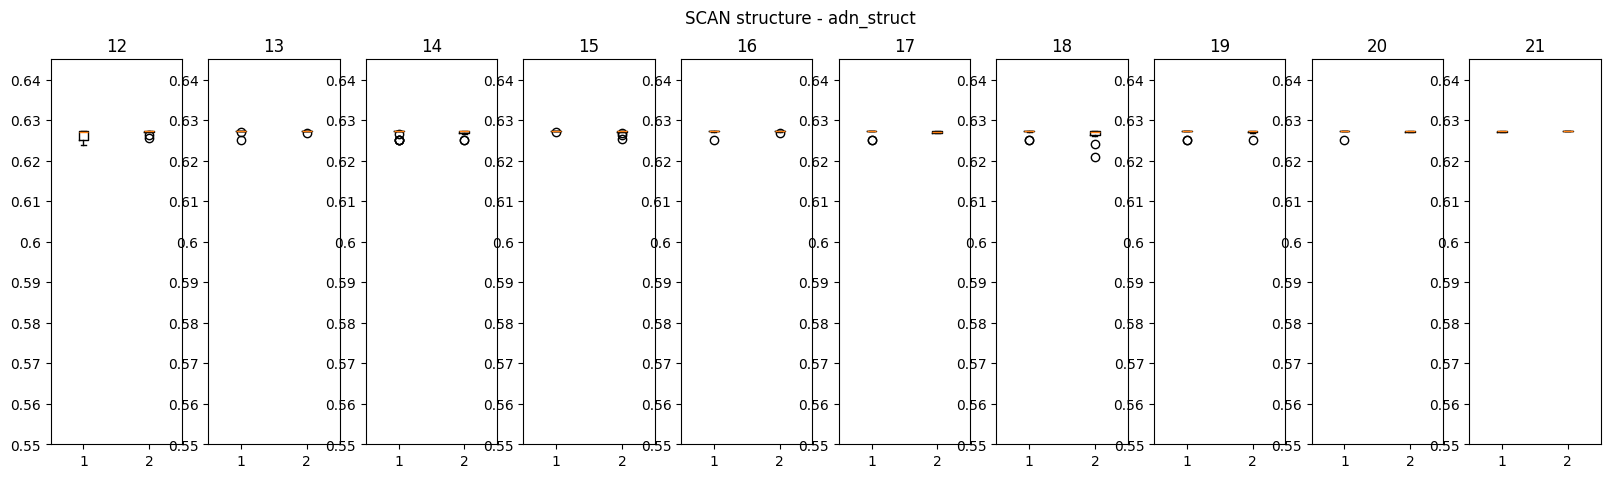

SCAN structure - presub_adult_struct has no data or 1 datapoint


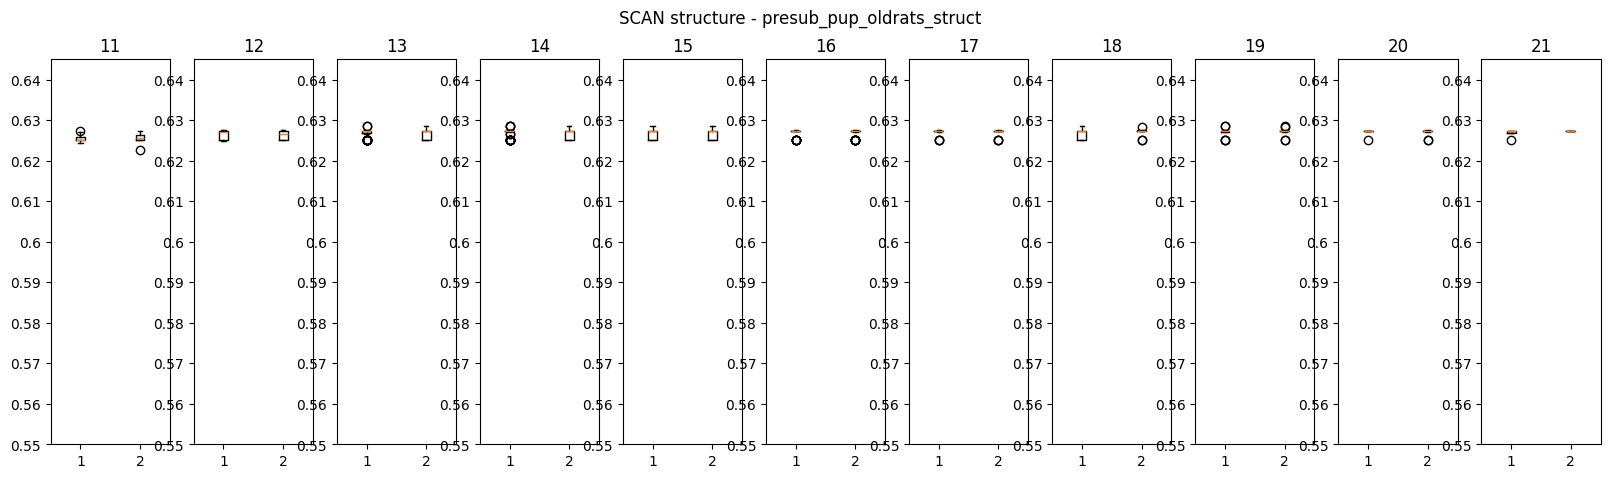

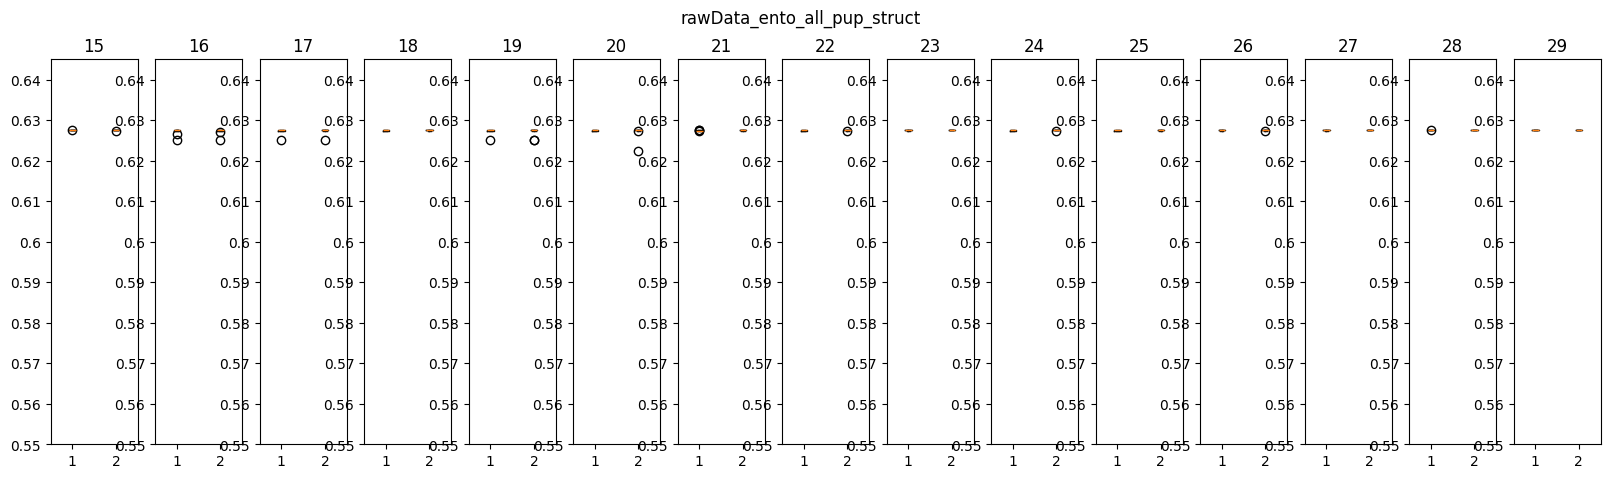


X (min, max): 0.005 0.6285653514739229
Y (min, max): 0.005 0.6285685067873303


In [14]:
from real_data_exploration.utils.process_data import plot_box_size_hist

plot_box_size_hist(box_size, BOX_LENGTH)

In [15]:
counter_by_age

{26: 21,
 20: 116,
 18: 114,
 19: 114,
 17: 104,
 28: 10,
 100: 214,
 22: 71,
 15: 142,
 31: 2,
 30: 5,
 16: 114,
 14: 121,
 24: 34,
 29: 6,
 25: 29,
 21: 61,
 27: 15,
 32: 1,
 23: 34,
 13: 116,
 12: 79,
 11: 10}

In [16]:
picked_by_age = {
    age: sorted(np.random.choice(
        range(c), min(config['MAX_SAMPLES_PER_AGE'], c), replace=False
    )) for age, c in counter_by_age.items()
}
picked_by_age

{26: [np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(5),
  np.int64(6),
  np.int64(7),
  np.int64(8),
  np.int64(9),
  np.int64(10),
  np.int64(11),
  np.int64(12),
  np.int64(13),
  np.int64(14),
  np.int64(15),
  np.int64(16),
  np.int64(17),
  np.int64(18),
  np.int64(19),
  np.int64(20)],
 20: [np.int64(0),
  np.int64(3),
  np.int64(5),
  np.int64(6),
  np.int64(8),
  np.int64(11),
  np.int64(13),
  np.int64(14),
  np.int64(15),
  np.int64(17),
  np.int64(20),
  np.int64(22),
  np.int64(25),
  np.int64(26),
  np.int64(28),
  np.int64(32),
  np.int64(36),
  np.int64(37),
  np.int64(39),
  np.int64(40),
  np.int64(41),
  np.int64(42),
  np.int64(43),
  np.int64(45),
  np.int64(46),
  np.int64(49),
  np.int64(51),
  np.int64(52),
  np.int64(54),
  np.int64(59),
  np.int64(62),
  np.int64(65),
  np.int64(66),
  np.int64(68),
  np.int64(70),
  np.int64(74),
  np.int64(75),
  np.int64(77),
  np.int64(80),
  np.int64(81),
  np.int64(82),
  np.int64(85)

In [17]:
x_all = {}
y_all = {}
hd_all = {}
speed_all = {}
rs_all = {}

for key_tuple in x_dict.keys():
    (ld, k, age, i_by_age) = key_tuple

    if i_by_age in picked_by_age[age]:
        x = x_dict[key_tuple]
        y = y_dict[key_tuple]
        hd = hd_dict[key_tuple]
        speed = speed_dict[key_tuple]
        rot_speed = rs_dict[key_tuple]

        # initialize all dict if first exp for this age
        if (ld, k, age) not in x_all.keys(): 
            x_all[(ld, k, age)] = []
            y_all[(ld, k, age)] = []
            hd_all[(ld, k, age)] = []
            speed_all[(ld, k, age)] = []
            rs_all[(ld, k, age)] = []

        x_all[(ld, k, age)].append(x)
        y_all[(ld, k, age)].append(y)
        hd_all[(ld, k, age)].append(hd)
        rs_all[(ld, k, age)].append(rot_speed)
        speed_all[(ld, k, age)].append(speed)
    else:
        dur_dict.pop(key_tuple)
        

In [18]:
print("Check if random sample succeeded:\n")

{
    a: (sum([len(x_all[k]) for k in x_all.keys() if k[2] == a]), counter_by_age[a])
    for a in sorted(counter_by_age.keys())
}

Check if random sample succeeded:



{11: (10, 10),
 12: (60, 79),
 13: (60, 116),
 14: (60, 121),
 15: (60, 142),
 16: (60, 114),
 17: (60, 104),
 18: (60, 114),
 19: (60, 114),
 20: (60, 116),
 21: (60, 61),
 22: (60, 71),
 23: (34, 34),
 24: (34, 34),
 25: (29, 29),
 26: (21, 21),
 27: (15, 15),
 28: (10, 10),
 29: (6, 6),
 30: (5, 5),
 31: (2, 2),
 32: (1, 1),
 100: (60, 214)}

##### Dataset, Rat, Duration by Age Distributions

In [19]:
lds = sorted(np.unique([k[0] for k in dur_dict.keys()]))
rats = sorted(np.unique([k[0]+k[1] for k in dur_dict.keys()]))
ages = sorted(np.unique([k[2] for k in dur_dict.keys()]))
ages_labels = [str(a) for a in ages]

In [20]:
ld_by_age = {
    a: [k[0] for k in dur_dict.keys() if k[2] == a]
    for a in ages
}

ld_counter = {}
for ld in lds:
    ld_counter[ld] = [np.sum([(ld==ld_sub) for ld_sub in ld_by_age[a]]) for a in ages]

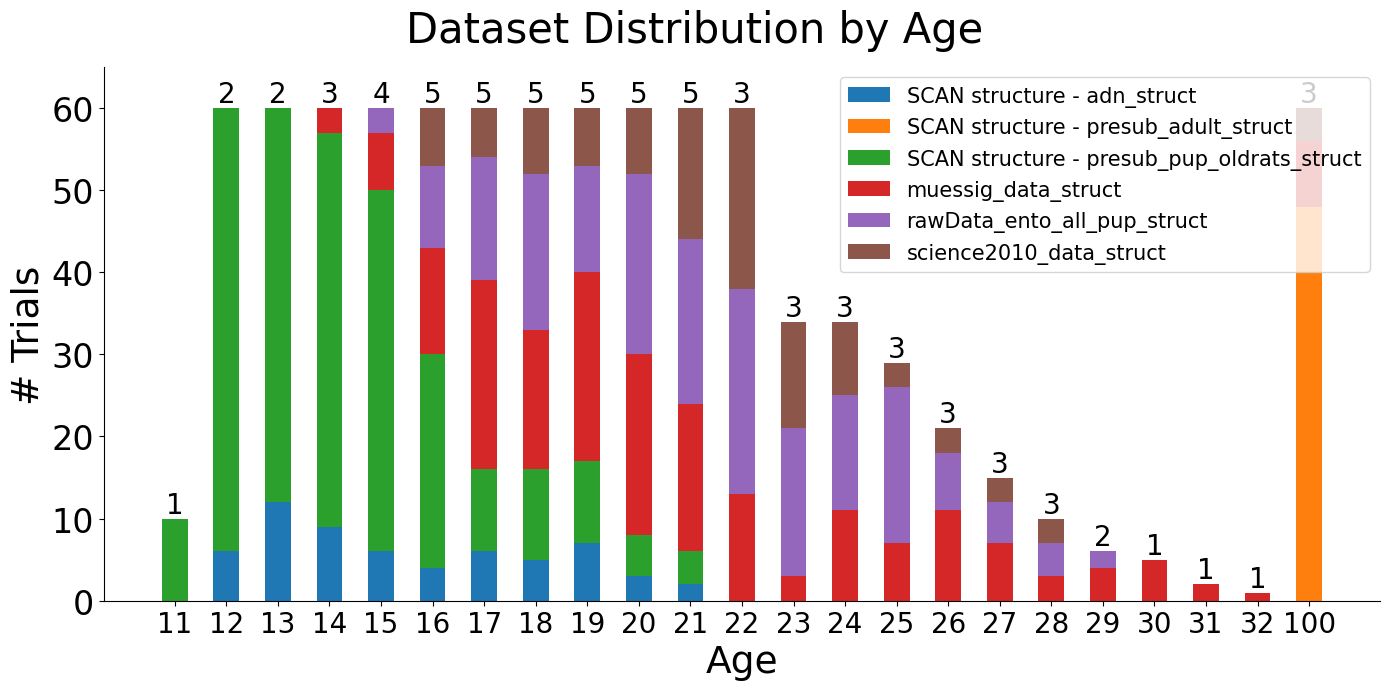

In [21]:
width = 0.5

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(ages))
i = 0

for ld, weight_count in ld_counter.items():
    p = ax.bar(
        ages_labels, weight_count, width,
        label=ld, bottom=bottom,
    )
    bottom += weight_count
    i += 1

for a, b in zip(ages_labels, bottom):
    n_unique = len(np.unique(ld_by_age[int(a)]))
    ax.text(a, b, str(n_unique), ha='center', va='bottom', fontsize=20)

plt.suptitle("Dataset Distribution by Age", fontsize=30)
plt.xticks(fontsize=20)
plt.yticks(fontsize=24)
plt.xlabel("Age", fontsize=27)
plt.ylabel("# Trials", fontsize=27)
plt.legend(fontsize=15)
plt.ylim([0, config['MAX_SAMPLES_PER_AGE']+5])

fig.axes[0].spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.show()

In [22]:
rat_by_age = {
    a: [k[0]+k[1] for k in dur_dict.keys() if k[2] == a]
    for a in ages
}

rat_counter = {}
for rat in rats:
    rat_counter[rat] = [np.sum([(rat==rat_sub) for rat_sub in rat_by_age[a]]) for a in ages]

/tmp/ipykernel_130401/3099332729.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


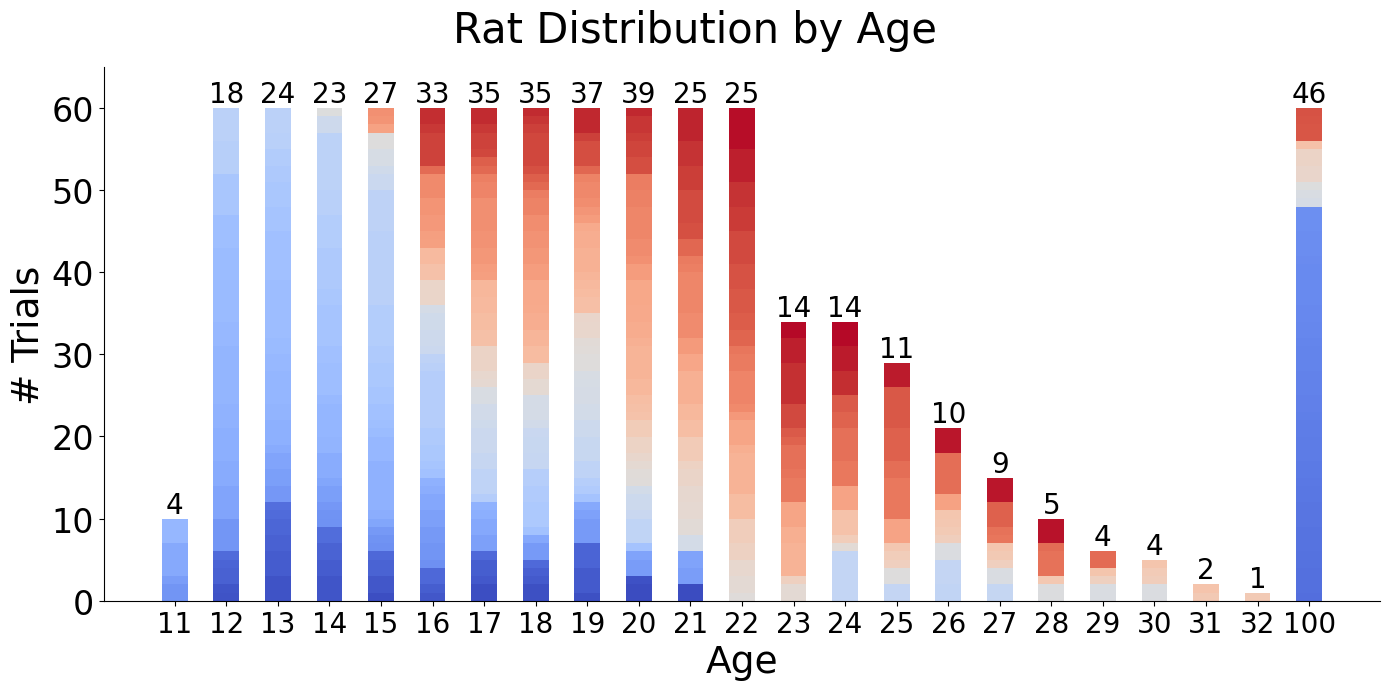

In [23]:
from matplotlib import cm

cmap = cm.get_cmap('coolwarm')

width = 0.5

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(ages))
i = 0

for rat, weight_count in rat_counter.items():
    p = ax.bar(
        ages_labels, weight_count, width,
        label=rat, bottom=bottom,
        color=cmap(i/len(rat_counter.keys()))
    )
    bottom += weight_count
    i += 1

for a, b in zip(ages_labels, bottom):
    n_unique = len(np.unique(rat_by_age[int(a)]))
    ax.text(a, b, str(n_unique), ha='center', va='bottom', fontsize=20)

plt.suptitle("Rat Distribution by Age", fontsize=30)
plt.xticks(fontsize=20)
plt.yticks(fontsize=24)
plt.xlabel("Age", fontsize=27)
plt.ylabel("# Trials", fontsize=27)
plt.ylim([0, config['MAX_SAMPLES_PER_AGE']+5])

fig.axes[0].spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.show()

In [25]:
dur_by_age = {
    a: [v for k,v in dur_dict.items() if k[2] == a]
    for a in ages
}

dur_counter = {}
for dur in sorted(np.unique(list(dur_dict.values()))):
    dur_counter[dur] = [np.sum([(dur==dur_sub) for dur_sub in dur_by_age[a]]) for a in ages]

/tmp/ipykernel_130401/591312288.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


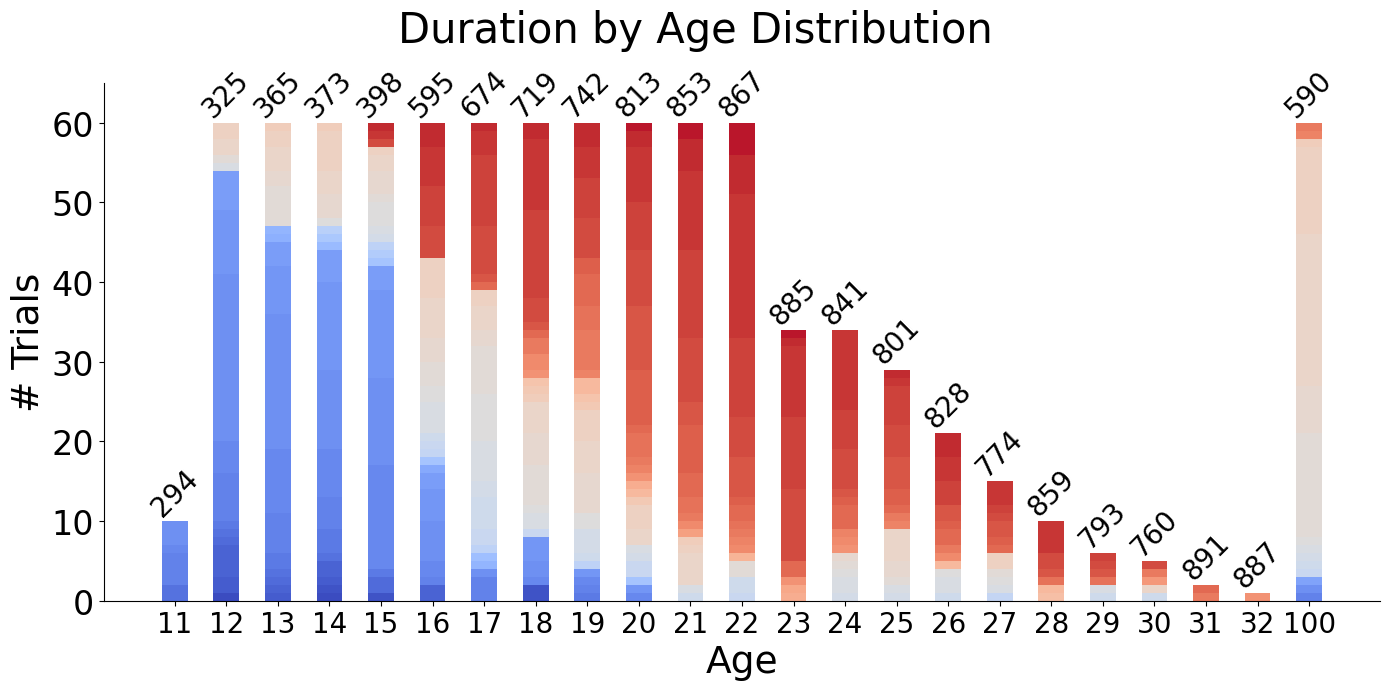

In [26]:
from matplotlib import cm

cmap = cm.get_cmap('coolwarm')

width = 0.5

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(ages))
i = 0

for dur, weight_count in dur_counter.items():
    p = ax.bar(
        ages_labels, weight_count, width,
        label=dur, bottom=bottom,
        color=cmap(i/len(dur_counter.keys()))
    )
    bottom += weight_count
    i += 1

for a, b in zip(ages_labels, bottom):
    avg_dur = np.mean(dur_by_age[int(a)])
    ax.text(a, b, f'{avg_dur:.0f}', ha='center', va='bottom', fontsize=20, rotation=45)

plt.suptitle("Duration by Age Distribution", fontsize=30)
plt.xticks(fontsize=20)
plt.yticks(fontsize=24)
plt.xlabel("Age", fontsize=27)
plt.ylabel("# Trials", fontsize=27)
plt.ylim([0, config['MAX_SAMPLES_PER_AGE']+5])

fig.axes[0].spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.show()

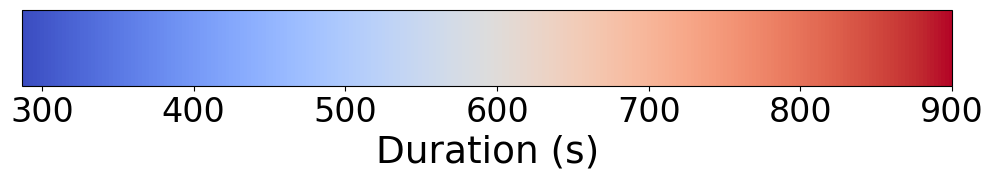

In [27]:
from matplotlib import colors, colorbar
fig, ax = plt.subplots(figsize=(12, 2))
fig.subplots_adjust(bottom=0.5)

cmap = cm.coolwarm
norm = colors.Normalize(
    vmin=min(list(dur_dict.values())), vmax=max(list(dur_dict.values()))
)
cbar = colorbar.ColorbarBase(
    ax, cmap=cmap, norm=norm, orientation='horizontal'
)
cbar.ax.tick_params(labelsize=24)

cbar.set_label('Duration (s)', fontsize=27)
plt.show()

### Speed and Rot Speed Histogram and Autocorr.

In [28]:
from real_data_exploration.utils.process_data import calculate_hist_occ


In [29]:
occ_s_dict = {}
occ_rs_dict = {}

for k_tuple in x_all.keys():
    if len(x_all[k_tuple]) == 0:
        print(f"No trials for {k_tuple}, skipping\n")
        continue
    print(k_tuple)
    
    occ_s_dict[k_tuple] = calculate_hist_occ(
        speed_all[k_tuple], config['SPEED_BINS'], config['SPEED_RANGE']
    )
    occ_rs_dict[k_tuple] = calculate_hist_occ(
        rs_all[k_tuple], config['RS_BINS'], [-np.pi, np.pi]
    )
    
    print()

('muessig_data_struct', 'r732_p26', 26)

('muessig_data_struct', 'r572_p20', 20)

('muessig_data_struct', 'r1776_p18', 18)

('muessig_data_struct', 'r1770_p19', 19)

('muessig_data_struct', 'r14_p18', 18)

('muessig_data_struct', 'r1776_p20', 20)

('muessig_data_struct', 'r67_p17', 17)

('muessig_data_struct', 'r379_p28', 28)

('muessig_data_struct', 'r98_p19', 19)

('muessig_data_struct', 'r711_p22', 22)

('muessig_data_struct', 'r118_p26', 26)

('muessig_data_struct', 'r716_p26', 26)

('muessig_data_struct', 'r732_p31', 31)

('muessig_data_struct', 'r739_p30', 30)

('muessig_data_struct', 'r378_p30', 30)

('muessig_data_struct', 'r72_p20', 20)

('muessig_data_struct', 'r66_p18', 18)

('muessig_data_struct', 'r663_p19', 19)

('muessig_data_struct', 'r66_p16', 16)

('muessig_data_struct', 'r1770_p15', 15)

('muessig_data_struct', 'r572_p22', 22)

('muessig_data_struct', 'r1771_p14', 14)

('muessig_data_struct', 'r1917_p19', 19)

('muessig_data_struct', 'r631_p18', 18)

('muessig_data_s

### Rat Positional Transition Matrix

##### TMs definition

In [30]:
from real_data_exploration.utils.transition_matrix_helper import generate_tm_loop

print(f"K: {K}\n")

tm_dict = {}
tm_occ = {}

for k_tuple in x_all.keys():
    if len(x_all[k_tuple]) == 0:
        print(f"No trials for {k_tuple}, skipping\n")
        continue
    print(k_tuple)

    tm_dict[k_tuple], tm_occ[k_tuple] = generate_tm_loop(
        x_all[k_tuple], y_all[k_tuple],
        BOX_LENGTH, B,
        config['DF'], DF_DAMP, K, config['ATOL'],
        config['SIGMA_SMOOTHING'], subsample=1, plot=False
    )

K: 350

('muessig_data_struct', 'r732_p26', 26)
('muessig_data_struct', 'r572_p20', 20)
('muessig_data_struct', 'r1776_p18', 18)
('muessig_data_struct', 'r1770_p19', 19)
('muessig_data_struct', 'r14_p18', 18)
('muessig_data_struct', 'r1776_p20', 20)
('muessig_data_struct', 'r67_p17', 17)
('muessig_data_struct', 'r379_p28', 28)
('muessig_data_struct', 'r98_p19', 19)
('muessig_data_struct', 'r711_p22', 22)
('muessig_data_struct', 'r118_p26', 26)
('muessig_data_struct', 'r716_p26', 26)
('muessig_data_struct', 'r732_p31', 31)
('muessig_data_struct', 'r739_p30', 30)
('muessig_data_struct', 'r378_p30', 30)
('muessig_data_struct', 'r72_p20', 20)
('muessig_data_struct', 'r66_p18', 18)
('muessig_data_struct', 'r663_p19', 19)
('muessig_data_struct', 'r66_p16', 16)
('muessig_data_struct', 'r1770_p15', 15)
('muessig_data_struct', 'r572_p22', 22)
('muessig_data_struct', 'r1771_p14', 14)
('muessig_data_struct', 'r1917_p19', 19)
('muessig_data_struct', 'r631_p18', 18)
('muessig_data_struct', 'r573_p2

##### TMs folding

In [31]:
from real_data_exploration.utils.transition_matrix_helper import reorder_transition_matrix

tm_reord_dict = {
    k_tuple: reorder_transition_matrix(tm_dict[k_tuple], B) for k_tuple in tm_dict.keys()
}

In [32]:
from real_data_exploration.utils.transition_matrix_helper import (
    fold_transition_matrix, reord_folded_transition_matrix, plot_all_transition_matrices
)

PLOT = False

tm_reord_fold_dict = {}
tm_fold_dict = {}

for k_tuple in tm_reord_dict.keys():
    tm_reord_quarter, tm_occ_quarter, tm_reord_half, tm_occ_half =\
        fold_transition_matrix(tm_dict[k_tuple], tm_reord_dict[k_tuple], B, HALF_IDX)
    tm_reord_fold_dict[k_tuple] = tm_reord_quarter

    tm_fold_dict[k_tuple] = reord_folded_transition_matrix(tm_reord_quarter, B)

    if PLOT:
        fig = plot_all_transition_matrices(
            tm_reord_dict[k_tuple], tm_reord_half, tm_reord_quarter,
            tm_occ[k_tuple], tm_occ_half, tm_occ_quarter, 
            B, HALF_IDX
        )
        plt.suptitle(k_tuple)
        plt.show()
        plt.close()

    tmp = np.sum(tm_fold_dict[k_tuple], axis=(-2,-1))
    assert np.allclose(tmp[tmp>0], 1, atol=config['ATOL'])

### Compare Experiments

In [33]:
save_dir = os.path.join(DATA_DIR, 'cluster_locomotion', 'by_day')
os.makedirs(save_dir, exist_ok=True)

In [ ]:
from real_data_exploration.utils.grid_search_helper import compare_parameters

df_data_dict = {}
df_data_name = f'data_{SEED}.pkl'
columns_data = ['speed', 'rs', 'x', 'y', 'hd']
indices_data = ['rat', 'age']

df_dict = {}
df_compare_name = f'compared_{SEED}.pkl'
columns_compare = [
    'speed_js', 'rs_js', 'tm_js',
]
indices_compare = ['rat_left', 'age_left', 'rat_right', 'age_right']

idx = 0

if os.path.exists(os.path.join(save_dir, df_data_name)) or\
    os.path.exists(os.path.join(save_dir, df_compare_name)):
    raise ValueError(f"{df_data_name} or {df_compare_name} already exist, delete it first")

k_tuple_all = sorted(occ_s_dict.keys())
for k_tuple in k_tuple_all:
    ld, rat, age = k_tuple
    print(f"({idx/len(k_tuple_all)*100:.0f}%) Saving data for {k_tuple}")
    
    df_data_dict[(str((ld, rat)), age)] = [
        speed_all[k_tuple], rs_all[k_tuple], x_all[k_tuple], y_all[k_tuple], hd_all[k_tuple]
    ]

    print(f"Comparing {k_tuple} with all other experiments")

    stime = time.time()
    # calculate behavioural metrisc errors
    (
        js_s_dict, js_rs_dict, js_tm_dict
    ) = compare_parameters(
        occ_s_dict, occ_s_dict[k_tuple],
        occ_rs_dict, occ_rs_dict[k_tuple],
        tm_fold_dict, tm_fold_dict[k_tuple],
    )

    etime = time.time()
    print(f"Metrics calculation took: {etime-stime:.2f} s")
    
    df_dict = {
        **df_dict,
        **{
            (str((ld, rat)), age, str((k[0], k[1])), k[2]) : [
                js_s_dict[k], js_rs_dict[k], js_tm_dict[k],
            ]  for k in js_s_dict.keys()
        }
    }
    print('\n', flush=True)
    idx += 1

df_data = pd.DataFrame(df_data_dict).T
df_data.columns = columns_data
df_data.index.names = indices_data
df_data.to_pickle(os.path.join(save_dir, df_data_name))

df_compare = pd.DataFrame(df_dict).T
df_compare.columns = columns_compare
df_compare.index.names = indices_compare
df_compare.to_pickle(os.path.join(save_dir, df_compare_name))